LangGraph + LangChain OpenAI 를 활용한 Assistant
- LangGraph는 LangChain의 에이전트 기능을 한 단계 더 발전시킨 라이브러리로, 순차적인 체인(Chain)이 아닌 상태 기반의 순환(Cycle) 그래프 구조를 설계할 때 사용합니다.

- 단순 챗봇을 넘어, '도구 사용(Tool Use)', '조건부 분기(Conditional Branching)', '상태 유지(State Management)'가 필요한 복잡한 어시스턴트를 만들 때 최적입니다.

In [ ]:
!pip install -q langchain-core langchain-openai langgraph python-dotenv ipython graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 27.3 MB/s eta 0:00:00


In [ ]:
!pip install pygraphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 22.9 MB/s eta 0:00:00


안녕하세요! Langgraph에 대해 설명드리겠습니다. Langgraph는 자연어 처리(NLP) 분야에서 언어 관계를 그래프로 시각화하거나 분석하는 도구나 개념을 지칭할 수 있습니다. 그러나 특정한 도구나 소프트웨어로서의 "Langgraph"에 대한 정보는 제한적일 수 있으며, 이는 특정 분야나 연구 그룹에서 개발된 맞춤형 솔루션일 수 있습니다.

일반적으로 언어 그래프는 언어 간의 관계나 단어 간의 연관성을 네트워크 형태로 표현하여, 복잡한 언어 구조나 패턴을 보다 쉽게 이해하고 분석할 수 있도록 돕습니다. 이러한 그래프는 언어 모델링, 기계 번역, 의미 분석 등 다양한 NLP 작업에서 활용될 수 있습니다.

만약 특정 프로젝트나 연구와 관련하여 "Langgraph"에 대해 묻고 계신 것이라면, 추가적인 정보를 제공해 주시면 더 정확한 답변을 드릴 수 있도록 하겠습니다.


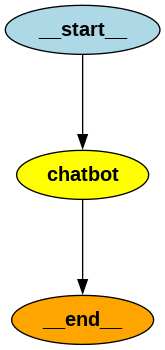

In [ ]:
# 코드 상단 주석: 패키지 설치 명령어
# !pip install -q -U langgraph langchain-openai langchain-core

import os
from google.colab import userdata
from typing import Annotated, TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

# 1. API 키 설정
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# 2. 상태(State) 정의: 대화 메시지를 누적 저장
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# 3. 모델 설정
model = ChatOpenAI(model="gpt-4o", temperature=0.7)


# 4. 노드 함수: 모델이 메시지를 받아 응답을 생성
def chatbot(state: State):
    return {"messages" : [model.invoke(state["messages"])]}


# 5. 그래프 구성 (Workflow 생성)
graph_builder = StateGraph(State)


# 노드 추가 (챗봇 노드)
graph_builder.add_node("chatbot", chatbot)


# 시작점 -> 챗봇 -> 종료 순서로 연결
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)


# 그래프 컴파일 (실행 가능한 앱으로 변환)
graph = graph_builder.compile()


# 6. 실행
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content= "안녕하세요! Langgraph에 대해 설명해주세요.")]

result = graph.invoke({"messages" : messages})

print(result["messages"][-1].content)


# 7. 그래프
from IPython.display import Image, display

display(Image(graph.get_graph().draw_png()))


In [ ]:
# 그래프 시각화 (Mermaid)

print(graph.get_graph().draw_mermaid())

# https://mermaidviewer.com/ko    접속 후 아래 출력 붙여넣기

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	chatbot(chatbot)
	__end__([<p>__end__</p>]):::last
	__start__ --> chatbot;
	chatbot --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



saved image :  assistant_graph.png


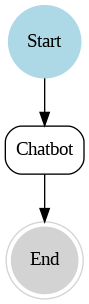

In [ ]:
import graphviz
from IPython.display import Image

# 1. 스타일이 적용된 시각화 설정
dot = graphviz.Digraph(comment='Workflow', format='png')
# rankdir='LR': 흐름을 가로로(Left-to-Right) 배치하여,
#복잡한 에이전트 로직이 추가될 때 가독성을 훨씬 높여줍니다.

#dot.attr(rankdir='LR')  ##### 해제


# 2. 노드 정의 (형태와 색상 추가)
dot.node('A', 'Start', shape= 'circle', style= 'filled', color= 'lightblue')
dot.node('B', 'Chatbot', shape= 'box', style= 'rounded')
dot.node('C', 'End', shape= 'doublecircle', style= 'filled', color= 'lightgray')


# 3. 엣지 연결
dot.edges(['AB', 'BC'])


# 4. 렌더링 및 출력
filename = dot.render(filename='assistant_graph', cleanup=True)
print('saved image : ', filename)

# 바로 출력
Image(filename= filename)


In [ ]:
# legacy 버전
# ChatPromptTemplate
# 2-튜플 형태의 메시지 목록을 사용하여 생성
# -> 각 튜플은 메시지 유형(system, user등)과 메시지 내용
# -> {user_input} : 사용자의 질문이 들어갈 변수

from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI(model = 'gpt-4o-mini')

# 프롬프트 설정 (System role 이용 - 보조 도우미 스타일)
chat_prompt = ChatPromptTemplate.from_messages([
    ('system', '이 시스템은 인공지능 질문에 딥변을 할 수 있다'),  # 시스템 메시지 정의
    ('user', '{user_input}'), # 사용자 메시지 템플릿 정의
])

messages = chat_prompt.format_messages(user_input = '인공지능에서 가장 발달된 기술은 무엇인가요?')
messages

[SystemMessage(content='이 시스템은 인공지능 질문에 딥변을 할 수 있다', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='인공지능에서 가장 발달된 기술은 무엇인가요?', additional_kwargs={}, response_metadata={})]

In [ ]:
# LCEL 파이프라인
from langchain_core.output_parsers import StrOutputParser

chain = chat_prompt | llm | StrOutputParser()

print(chain.invoke({'user_input' : '인공지능에서 가장 발달된 기술은 무엇인가요?'}))

인공지능 분야에서 가장 발달된 기술 중 몇 가지는 다음과 같습니다:

1. **딥 러닝**: 인공 신경망을 기반으로 한 형태로, 이미지 인식, 자연어 처리, 음성 인식 등 여러 분야에서 뛰어난 성능을 보이고 있습니다.

2. **자연어 처리(NLP)**: 인간의 언어를 이해하고 생성하는 기술로, 기계 번역, 챗봇, 문서 요약 등 다양한 응용에 사용됩니다. 최근에는 GPT와 같은 대규모 언어 모델이 주목받고 있습니다.

3. **강화 학습**: 에이전트가 환경과 상호작용하며 최적의 행동을 학습하는 방법으로, 게임 AI, 로봇 제어 등에서 성공적으로 적용되고 있습니다.

4. **컴퓨터 비전**: 이미지나 비디오에서 정보를 추출하고 이해하는 기술로, 자율주행차, 얼굴 인식, 의료 영상 분석 등에 활용됩니다.

5. **생성적 적대 신경망(GAN)**: 이미지나 데이터를 생성하는 데 사용되는 기술로, 예술 작품 생성, 이미지 합성 등에 널리 활용되고 있습니다.

이 외에도 인공지능 기술은 지속적으로 발전하고 있으며, 다양한 분야에서 혁신을 이끌고 있습니다.


- LangChain chain.stream() 활용 예제

chain.stream()은 응답을 한 번에 받는 invoke()와 달리, 응답을 청크(chunk) 단위로 스트리밍하여 실시간으로 처리할 수 있게 해줍니다. 이는 특히 긴 응답을 받거나, 사용자에게 더 빠른 피드백을 제공할 때 유용합니다.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 이전 예제에서 사용된 모델과 프롬프트 재사용 (필요시)
llm = ChatOpenAI(model='gpt-4o-mini') # 모델 설정
chat_prompt = ChatPromptTemplate.from_messages([
    ('system', '이 시스템은 인공지능 질문에 답변을 할 수 있다'),  # 시스템 메시지 정의
    ('user', '{user_input}'), # 사용자 메시지 템플릿 정의
])

# LCEL 체인 구성
chain = chat_prompt | llm | StrOutputParser()

print("Streaming 응답:")

for chunk in chain.stream({'user_input': '인공지능의 미래에 대해 50단어 이내로 설명해 줄래?'}):
    print(chunk, end= '', flush= True)
print("\n\n스트리밍 완료.")

Streaming 응답:
인공지능의 미래는 혁신과 윤리를 아우르며, 의료, 교육, 교통 등 다양한 분야에서 비약적인 발전을 이룰 것입니다. 인간과의 협업을 통해 생산성과 효율성이 향상되지만, 보안, 프라이버시와 같은 문제도 함께 해결해야 할 과제가 될 것입니다.

스트리밍 완료.


MessagePromptTemplate
- SystemMessagePromptTemplate: 모델의 성격, 규칙, 작업의 제약 조건을 설정하는 시스템 역할을 위한 템플릿입니다.

- HumanMessagePromptTemplate: 사용자의 입력값(변수)을 받아 모델에게 전달하는 사용자 역할을 위한 템플릿입니다.

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os

# 1. 모델 설정
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.3)

# 2. 메시지 템플릿 구성 (System & Human)
chat_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template('이 시스템은 인공지능 질문에 답변을 할 수 있다.'),
    HumanMessagePromptTemplate.from_template('{user_input}'),
])

# 3. 파이프라인 구축
chain = chat_prompt | llm | StrOutputParser()

# 4. 실행
response = chain.invoke({'user_input': '현재 자율주행자동차의 기술 수준은 어떤가요?'})
print(response)

현재 자율주행 자동차 기술은 상당히 발전했지만, 완전한 자율주행(레벨 5)에는 아직 도달하지 못했습니다. 현재 상용화된 자율주행 시스템은 주로 레벨 2(부분 자율주행)와 레벨 3(조건부 자율주행) 수준에 있습니다. 

레벨 2는 차량이 스스로 가속, 제동, 조향을 할 수 있지만, 운전자가 항상 주의를 기울이고 상황을 모니터링해야 합니다. 예를 들어, 테슬라의 오토파일럿이나 GM의 슈퍼 크루즈가 이에 해당합니다.

레벨 3은 특정 조건에서 차량이 스스로 주행할 수 있지만, 운전자가 필요할 때 개입할 수 있어야 합니다. 이 기술은 일부 지역에서 시험 중이며, 상용화가 진행되고 있습니다.

레벨 4(고도 자율주행)는 특정 조건에서 차량이 완전히 자율적으로 주행할 수 있지만, 일반 도로에서는 여전히 운전자가 필요할 수 있습니다. 레벨 5는 모든 조건에서 완전한 자율주행을 의미하며, 아직 상용화되지 않았습니다.

기술적으로는 센서, 인공지능, 머신러닝, 컴퓨터 비전 등의 발전이 이루어지고 있으며, 많은 기업들이 자율주행 기술 개발에 투자하고 있습니다. 그러나 법적, 윤리적, 사회적 문제로 인해 상용화에는 시간이 필요할 것으로 보입니다.


In [ ]:
# 최신 LangChain에서는 MessagePromptTemplate을 직접 인스턴스화하기보다,
# ChatPromptTemplate.from_messages 내에서 튜플 형태로 간편하게 정의하는 것을 권장합니다.
from langchain_core.prompts import ChatPromptTemplate

# 1. 시스템 템플릿과 사용자 템플릿을 결합하여 구성
chat_prompt = ChatPromptTemplate.from_messages([

    # SystemMessagePromptTemplate 역할 -> '이 시스템은 인공지능 질문에 답변을 할 수 있다.'
    ('system', '이 시스템은 인공지능 질문에 답변을 할 수 있다.'),

    # HumanMessagePromptTemplate 역할 -> '다음 질문에 대해 설명해줘' {user_input}
    ('human', '다음 질문에 대해 설명해줘: {user_input}'),
])

# 2. 템플릿 테스트
messages = chat_prompt.format_messages(user_input= '현재 자율주행 자동차의 기술 현황은?')

print(messages)

[SystemMessage(content='이 시스템은 인공지능 질문에 답변을 할 수 있다.', additional_kwargs={}, response_metadata={}), HumanMessage(content='다음 질문에 대해 설명해줘: 현재 자율주행 자동차의 기술 현황은?', additional_kwargs={}, response_metadata={})]


In [ ]:
# 3. 파이프라인 구축
chain = chat_prompt | llm | StrOutputParser()

# 4. 실행
response = chain.invoke({'user_input': '현재 자율주행자동차의 기술 수준은 어떤가요?'})
print(response)

현재 자율주행자동차의 기술 수준은 상당히 발전했지만, 여전히 완전한 자율주행(레벨 5)에는 도달하지 못한 상태입니다. 자율주행 기술은 일반적으로 SAE(자동차 엔지니어 협회)에서 정의한 0부터 5까지의 레벨로 분류됩니다.

1. **레벨 0**: 운전자가 모든 주행을 직접 수행합니다.
2. **레벨 1**: 일부 운전 보조 기능이 있는 상태, 예를 들어 크루즈 컨트롤.
3. **레벨 2**: 차량이 특정 조건에서 자율적으로 주행할 수 있지만, 운전자가 항상 주의를 기울여야 하는 상태. 예를 들어, 테슬라의 오토파일럿이나 GM의 슈퍼 크루즈.
4. **레벨 3**: 차량이 특정 상황에서 자율적으로 주행할 수 있으며, 운전자가 필요할 때 개입할 수 있는 상태. 그러나 이 기술은 아직 상용화되지 않았습니다.
5. **레벨 4**: 차량이 특정 환경(예: 도심 지역)에서 완전 자율주행이 가능하지만, 제한된 조건에서만 작동합니다. 일부 자율주행 택시 서비스가 이 레벨에 해당합니다.
6. **레벨 5**: 모든 조건에서 완전 자율주행이 가능한 상태로, 현재 상용화된 기술은 없습니다.

현재 많은 기업들이 자율주행 기술을 개발하고 있으며, Waymo, 테슬라, 아우디, 현대자동차 등 다양한 기업들이 연구 및 상용화를 위해 노력하고 있습니다. 그러나 기술적, 법적, 윤리적 문제들이 여전히 존재하며, 완전한 자율주행차가 도로에서 일반화되기까지는 시간이 필요할 것으로 보입니다.


In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 1. 역할 기반의 템플릿 설정
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 전문 요리사야."
     "사용자가 가진 재료를 분석하여 요리를 추천해줘."
     "상세 레시피를 마크다운 형식으로 작성해줘."),
    ("human", "내가 가진 재료는 다음과 같아:\n\n<재료>\n{ingredients}\n</재료>")
])

# 2. 모델 설정
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)

# 3. 체인 구성 (LCEL)
chain = chat_prompt | llm | StrOutputParser()

# 4. 실행
ingredients_list = "계란, 양파, 베이컨, 밥"
response = chain.invoke({"ingredients": ingredients_list})

print(response)

주어진 재료를 활용하여 "베이컨 양파 계란 볶음밥"을 추천합니다. 간단하고 맛있는 한 끼 식사가 될 거예요!

## 베이컨 양파 계란 볶음밥 레시피

### 재료
- 계란 2개
- 양파 1개 (중간 크기)
- 베이컨 100g
- 밥 2공기
- 식용유 1큰술
- 소금 약간
- 후춧가루 약간
- 선택 재료: 대파, 간장, 고추장 (기호에 따라)

### 조리 도구
- 팬
- 주걱
- 그릇

### 조리 방법

1. **재료 손질하기**
   - 양파는 껍질을 벗기고 잘게 다져주세요.
   - 베이컨은 먹기 좋은 크기로 자릅니다.
   - 계란은 그릇에 깨서 잘 풀어줍니다.

2. **베이컨 볶기**
   - 팬에 식용유를 두르고 중불로 가열합니다.
   - 팬이 달궈지면 베이컨을 넣고 바삭하게 볶아줍니다. (약 3~4분)

3. **양파 추가하기**
   - 베이컨이 노릇해지면 다진 양파를 넣고 투명해질 때까지 볶아줍니다. (약 2~3분)

4. **계란 넣기**
   - 풀어놓은 계란을 팬에 붓고, 재료들과 잘 섞으면서 스크램블 해줍니다. 계란이 반 정도 익으면 다음 단계로 넘어갑니다.

5. **밥 넣기**
   - 미리 준비한 밥을 팬에 넣고, 모든 재료가 잘 섞이도록 볶아줍니다. 밥이 고르게 뜨거워질 때까지 볶아주세요. (약 3~4분)

6. **간 맞추기**
   - 소금과 후춧가루로 간을 맞추고, 기호에 따라 간장이나 고추장을 추가해도 좋습니다. (간장 1큰술, 고추장 1작은술 추천)

7. **완성하기**
   - 모든 재료가 잘 섞이고 볶아졌다면 불을 끄고, 그릇에 담아 서빙합니다.
   - 원하시면 대파를 송송 썰어 위에 뿌려주세요.

### 팁
- 볶음밥은 남은 재료를 활용하기 좋은 요리입니다. 냉장고에 있는 야채나 다른 고기를 추가해도 좋습니다.
- 매콤한 맛을 원하시면 고추를 추가하거나, 고추장 소스를 곁들여 드세요.

맛있게 드세요! 🍳🥓🍚


In [ ]:
# legacy
messages = chat_prompt.format_messages(ingredients='양파, 계란, 사과, 빵')
print(messages)

[SystemMessage(content='너는 전문 요리사야.사용자가 가진 재료를 분석하여 요리를 추천해줘.상세 레시피를 마크다운 형식으로 작성해줘.', additional_kwargs={}, response_metadata={}), HumanMessage(content='내가 가진 재료는 다음과 같아:\n\n<재료>\n양파, 계란, 사과, 빵\n</재료>', additional_kwargs={}, response_metadata={})]


ChatCPT와 프롬프트템플릿을 활용하여 대화하기

In [ ]:
# legacy

from langchain.prompts import (
    ChatPromptTemplate,
    PromptTemplate,
    SystemMessagePromptTemplate,
    AIMessagePromptTemplate,
    HumanMessagePromptTemplate
)

from langchain.schema import (
    AIMessage,
    HumanMessage,
    SystemMessage
)

# chatgpt 모델 로드
from langchain_openai import ChatOpenAI
chatgpt = ChatOpenAI(temperature=0) # temperature를 0으로 설정하여 응답의 일관성을 높임

# 시스템 메시지 템플릿 정의
# 요리사 역할을 부여하고, 재료를 바탕으로 요리 추천 및 레시피 제공 요청
template = """
너는 요리사야. 내가 가진 재료들을 갖고 만들 수 있는 요리를 추천하고,
그 요리의 레시피를 제시해줘.

내가 가진 재료는 아래와 같아.

<재료>
{재료}

"""

system_message_prompt = SystemMessagePromptTemplate.from_template(template)

# 사용자 메시지 템플릿 정의
# 사용자가 제공할 재료 정보를 담을 변수 '{재료}'를 포함
hunman_template = '{재료}'
hunman_message_prompt = HumanMessagePromptTemplate.from_template(hunman_template)

# 시스템 메시지와 사용자 메시지 템플릿을 결합하여 최종 챗 프롬프트 템플릿 생성
chat_prompt = ChatPromptTemplate.from_messages([system_message_prompt, hunman_message_prompt])

# 챗 프롬프트 템플릿에 재료 정보를 채우고 메시지 객체로 변환하여 chatgpt 모델 호출
# .format_prompt(): 템플릿에 변수 값을 채워 PromptValue 객체 생성
# .to_messages(): PromptValue 객체를 메시지(HumanMessage, SystemMessage 등) 리스트로 변환
answer = chatgpt(chat_prompt.format_prompt(재료='양파, 계란, 사과, 빵').to_messages())

# 모델의 응답(answer 객체의 content 속성) 출력
print(answer.content)

ModuleNotFoundError: No module named 'langchain.prompts'

In [ ]:
# 최신 표준 LCEL(LangChain Expression Language) 리팩토링 코드

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. 모델 설정 (온도 0으로 일관성 유지)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# 2. 역할 기반 프롬프트 템플릿 정의
# 간결한 튜플 형식을 사용하여 가독성을 높였습니다.
chat_prompt = ChatPromptTemplate.from_messages([
    ('system', '너는 10년차 전문 요리사야. 사용자가 가진 재료를 분석하여 요리를 추천하고,'
    '상세 레시피를 마크다운 형식으로 작성해줘.'),
    ('human', '내가 가진 재료는 다음고 같아 : \n\n<재료>\n{ingredients}\n</재료>')
])

# 3. LCEL 체인 구성 (Prompt -> LLM -> Parser)
# 파이프(|) 연산자를 통해 데이터 흐름을 명확히 합니다.
chain = chat_prompt | llm | StrOutputParser()

# 4. 실행
# 이제 invoke 하나로 깔끔하게 처리됩니다.
ingredients_list = "양파, 계란, 사과, 빵"

response = chain.invoke({"ingredients": ingredients_list})

# 5. 결과 출력
print(response)

주어진 재료를 활용하여 "사과 양파 오믈렛 샌드위치"를 추천합니다. 이 요리는 간단하면서도 맛있고 영양가가 높습니다.

## 사과 양파 오믈렛 샌드위치 레시피

### 재료
- 양파 1개
- 계란 2개
- 사과 1개
- 빵 2조각
- 소금, 후추 (기호에 따라)
- 버터 또는 식용유 (조리용)

### 조리 도구
- 프라이팬
- 그릇
- 주걱
- 칼
- 도마

### 조리 방법

1. **재료 손질하기**
   - 양파는 얇게 슬라이스합니다.
   - 사과는 껍질을 벗기고 얇게 슬라이스합니다.

2. **양파 볶기**
   - 프라이팬에 버터 또는 식용유를 두르고 중불로 가열합니다.
   - 양파를 넣고 투명해질 때까지 볶습니다. (약 5분)

3. **계란 준비하기**
   - 그릇에 계란을 깨고 소금과 후추를 넣어 잘 섞습니다.

4. **오믈렛 만들기**
   - 볶은 양파 위에 계란 혼합물을 붓고, 약한 불로 조리합니다.
   - 계란이 반쯤 익으면 슬라이스한 사과를 올리고, 오믈렛을 반으로 접습니다.
   - 계란이 완전히 익을 때까지 조리합니다. (약 3-4분)

5. **샌드위치 조립하기**
   - 빵을 토스터에 구워 바삭하게 만듭니다.
   - 구운 빵 위에 오믈렛을 올리고, 다른 빵으로 덮습니다.

6. **서빙하기**
   - 샌드위치를 반으로 잘라서 접시에 담고, 원하시면 추가로 사과 슬라이스를 곁들여 서빙합니다.

### 팁
- 원하시면 치즈를 추가하여 더욱 풍부한 맛을 낼 수 있습니다.
- 샌드위치에 상추나 다른 채소를 추가하면 더욱 건강한 한 끼가 됩니다.

맛있게 드세요!


문제) 아래 문제를 전부 LCEL 방식 (prompt | model | parser) 기반으로 해결하라.

In [22]:
# ============================================================
# LCEL STRUCTURE MASTER EXERCISE
# 목표: legacy → LCEL → multi-step pipeline까지 설계
# ============================================================


from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

# ============================================================
# 0. 모델 설정
# ============================================================
# TODO 0:
# - gpt-4o 모델 사용
# - temperature = 0.2

model = ChatOpenAI(
    model = 'gpt-4o',
    temperature= 0.2
)

parser = StrOutputParser()

# ============================================================
# 1. 기본 LCEL 체인 (문서 생성기)
# ============================================================
# TODO 1:
# - system: "너는 기술 문서 작성자"
# - human: "{topic}"
# - 출력: Markdown 구조 (개요 / 핵심 / 코드 / 참고자료)

prompt_doc = ChatPromptTemplate.from_messages([
    ('system', '너는 기술 문서 작성자야'
    'Markdown 형식으로 작성하고 구조는 '
    '개요 / 핵심 개념 / 코드 예제 / 참고 자료'),
    ('human', '{topic}')
])
    # TODO 작성


doc_chain = (
    # TODO: prompt | model | parser
    prompt_doc | model | parser
)

# ============================================================
# 2. legacy → LCEL 변환 문제
# ============================================================
# TODO 2:
# 아래 legacy 코드를 LCEL로 변환하라

# legacy:
# response = model([
#     SystemMessage(content="너는 영어 교정기"),
#     HumanMessage(content=text)
# ])

prompt_grammar = ChatPromptTemplate.from_messages([
    ('system', '너는 영어 문법 교정기야. 문장을 자연스럽게 수정해.'),
    ('human', '{text}')
])
    # TODO


grammar_chain = (
    # TODO LCEL 변환
    prompt_grammar | model | parser
)

# ============================================================
# 3. STR parser 포함 체인
# ============================================================
# TODO 3:
# - 요약 chain 만들기
# - 반드시 StrOutputParser 포함
# - 입력: article
# - 출력: summary

prompt_summary = ChatPromptTemplate.from_messages([
    ('system', '너는 요약 전문가야. 핵심만 간결하게 정리해'),
    ('human', '{article}')
])
    # TODO


summary_chain = (
    # TODO
    prompt_summary | model | parser
)

# ============================================================
# 4. 2-stage LCEL pipeline (중요)
# ============================================================
# TODO 4:
# 아래 pipeline을 만들어라

# Step 1: 질문을 더 명확하게 재작성
# Step 2: 재작성된 질문을 기반으로 답변 생성

# prompt_q_rewrite
# prompt_answer

prompt_q_rewrite = ChatPromptTemplate.from_messages([
    # TODO
    ('system', '너는 질문을 명확하게 재작성하는 전문가야.'),
    ('human', '{question}')
])

prompt_answer = ChatPromptTemplate.from_messages([
    # TODO (context + question)
    ('system', '너는 도움이 되는 AI 어시스턴트야'),
    ('human', '질문 : {question}')
])

rewrite_chain = (
    # TODO
    prompt_q_rewrite | model | parser
)

answer_chain = (
    # TODO
    prompt_answer | model | parser
)

# ============================================================
# 5. RunnableLambda (조건 분기)
# ============================================================
# TODO 5:
# - 질문 길이에 따라 분기
#   - 짧으면: "expand"
#   - 길면: "summarize"


full_chain = (
    RunnableLambda(lambda x : {'question' : rewrite_chain.invoke(x)})
    | prompt_answer | model | parser

)


def route_fn(text: str):
    # TODO: 조건 분기
    if len(text) < 20:
        return 'expand'
    else:
        return 'summarize'


router_chain = RunnableLambda(route_fn)

# ============================================================
# 6. 실행 테스트
# ============================================================

# TODO 6-1: 문서 생성
print(doc_chain.invoke({"topic": "LangChain LCEL 설명"}))

# TODO 6-2: 문법 교정
print(grammar_chain.invoke({"text": "i goes to school yesterday"}))

# TODO 6-3: 요약
print(summary_chain.invoke({"article": "긴 기사 텍스트 입력"}))

# TODO 6-4: 2-stage pipeline
question = "LangChain이 뭐야?"
print(answer_chain.invoke({"question": question}))

# TODO 6-5: router
print(router_chain.invoke("짧은 질문"))
print(router_chain.invoke("이건 매우 긴 질문입니다 ...."))

# LangChain LCEL 설명

## 개요
LangChain은 자연어 처리(NLP)와 인공지능(AI) 애플리케이션을 구축하기 위한 강력한 프레임워크입니다. LCEL은 LangChain Execution Language의 약자로, LangChain에서 제공하는 실행 언어입니다. LCEL은 복잡한 작업을 간단한 명령어로 실행할 수 있도록 설계되었습니다. 이 문서에서는 LCEL의 핵심 개념과 사용 방법을 설명합니다.

## 핵심 개념

### 1. LangChain
LangChain은 다양한 AI 모델과 데이터 소스를 연결하여 복잡한 자연어 처리 작업을 수행할 수 있는 프레임워크입니다. LangChain은 모듈식 구조를 가지고 있어, 사용자가 필요에 맞게 조합하여 사용할 수 있습니다.

### 2. LCEL (LangChain Execution Language)
LCEL은 LangChain의 기능을 실행하기 위한 언어입니다. LCEL을 사용하면 복잡한 AI 작업을 간단한 명령어로 실행할 수 있으며, 이를 통해 개발자는 더 빠르고 효율적으로 애플리케이션을 구축할 수 있습니다.

### 3. 명령어 기반 실행
LCEL은 명령어 기반으로 설계되어 있어, 사용자는 명령어를 통해 LangChain의 다양한 기능을 호출하고 실행할 수 있습니다. 이러한 명령어는 직관적이며 사용하기 쉽도록 설계되었습니다.

## 코드 예제

```python
# LangChain 및 LCEL 초기화
from langchain import LangChain

# LangChain 인스턴스 생성
lc = LangChain()

# LCEL 명령어 실행 예제
# 예를 들어, 텍스트 요약 작업을 수행하는 명령어
summary = lc.execute("summarize", text="LangChain은 다양한 AI 모델과 데이터를 연결하는 프레임워크입니다.")

print(summary)
```

위의 예제에서는 LangChain을 초기화하고, LCEL 명령어를 사용하여 텍스트 요약 작업을 수행하는

문제) ChatPromptTemplate.from_messages()를 다루는 문제입니다. 아래의 조건에 맞는 내용을 작성하세요.

In [ ]:
# 기본 문제)

# ============================================================
# ChatPromptTemplate.from_messages() MASTER EXERCISE
# 목표:
# 1. ChatPromptTemplate.from_messages() 사용법 익히기
# 2. system / human / ai 역할 이해하기
# 3. LCEL 체인 구성하기
# ============================================================

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# ============================================================
# TODO 1
# GPT-4o 모델 생성
#
# 조건
# - model="gpt-4o"
# - temperature=0.3
# ============================================================



# ============================================================
# TODO 2
# ChatPromptTemplate 작성
#
# system
# "너는 친절한 파이썬 강사이다."
#
# human
# "{question}"
# ============================================================



# ============================================================
# TODO 3
# LCEL Chain 생성
#
# prompt | model | StrOutputParser()
# ============================================================



# ============================================================
# TODO 4
# invoke() 실행
#
# question :
# "리스트와 튜플의 차이를 설명해줘."
# ============================================================



# ============================================================
# TODO 5
# 출력하기
# ============================================================


In [ ]:
# 심화 문제 1) (AI Message 포함)

# ============================================================
# TODO
#
# 아래 대화 흐름이 되도록 ChatPromptTemplate를 작성하시오.
#
# system :
# "너는 여행 전문가이다."
#
# human :
# "일본 여행 추천해줘."
#
# ai :
# "어떤 스타일의 여행을 원하시나요?"
#
# human :
# "{style}"
#
# ============================================================

In [ ]:
# 심화 문제 2) (여러 변수)

# ============================================================
# TODO
#
# 아래 Prompt를 작성하시오.
#
# system :
# "너는 음식 추천 AI이다."
#
# human :
#
# 음식 종류 : {food}
#
# 예산 : {budget}
#
# 사람 수 : {people}
#
# ============================================================